# Raw Data Analysis - Inverter Telemetry

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

INVERTER_RAW_PATH = "../data/bronze/inverter_raw.csv"

In [ ]:
def load_csv(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    if not lines:
        return pd.DataFrame()

    # 1. Get header and count target columns
    header = lines[0].strip().split(',')
    num_cols = len(header)
    
    # 2. Find where the JSON is (it's always the column before the last 4)
    # The last 4 are always: ingestion_timestamp, source, processing_status, error_message
    json_idx = header.index('raw_json')
    cols_after_json = num_cols - (json_idx + 1)

    data_rows = []
    for line in lines[1:]:
        line = line.strip()
        if not line:
            continue
        
        parts = line.split(',')
        
        # Leading columns (before JSON)
        leading = parts[:json_idx]
        
        # Trailing columns - take exactly the last cols_after_json columns
        trailing = parts[-cols_after_json:]

        # Everything in between is the JSON
        json_parts = parts[json_idx:-cols_after_json]
        json_blob = ",".join(json_parts).strip('"')

        # Combine and ensure we only have the exact number of columns as the header
        full_row = leading + [json_blob] + trailing
        data_rows.append(full_row[:num_cols])

    # Drop columns that are entirely empty or whitespace-only like 'error_message'
    df = pd.DataFrame(data_rows, columns=header)
    df = df.replace(r"^\s*$", pd.NA, regex=True)
    df = df.dropna(axis=1, how='all')

    return df

## Load data and check general properties

In [6]:
inverter_raw = load_csv(INVERTER_RAW_PATH)
inverter_raw.head()

,id,plant_id,inverter_id,timestamp,state,inverter_temp_c,ac_power_kw,ac_freq_hz,dc_power_kw,dc_voltage_v,dc_current_a,healthy_strings,failed_strings,active_failures,failure_types,raw_json,ingestion_timestamp,source,processing_status
0,6404,d8164055-4101-4443-9540-74249ee8a9bc,C1,2026-02-02 01:23:42.606193+00,2,19.52,0.000,0.00,0.000,0.00,0.00,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:47:04.745274+00,kafka,processed
1,239,d8164055-4101-4443-9540-74249ee8a9bc,C0,2026-02-01 19:53:28.851995+00,2,19.51,0.000,0.00,0.000,0.00,0.00,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:25.573412+00,kafka,processed
2,240,d8164055-4101-4443-9540-74249ee8a9bc,A2,2026-02-01 19:53:58.961232+00,2,19.36,0.000,0.00,0.000,0.00,0.00,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:25.580091+00,kafka,processed
3,241,d8164055-4101-4443-9540-74249ee8a9bc,A0,2026-02-01 19:53:25.598663+00,2,19.75,0.000,0.00,0.000,0.00,0.00,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:25.581264+00,kafka,processed
4,242,d8164055-4101-4443-9540-74249ee8a9bc,B2,2026-02-01 19:53:34.817008+00,2,19.92,0.000,0.00,0.000,0.00,0.00,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:25.58131+00,kafka,processed


In [7]:
inverter_raw.shape

(1788288, 19)

In [8]:
inverter_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1788288 entries, 0 to 1788287
Data columns (total 19 columns):
 #   Column               Dtype
---  ------               -----
 0   id                   str  
 1   plant_id             str  
 2   inverter_id          str  
 3   timestamp            str  
 4   state                str  
 5   inverter_temp_c      str  
 6   ac_power_kw          str  
 7   ac_freq_hz           str  
 8   dc_power_kw          str  
 9   dc_voltage_v         str  
 10  dc_current_a         str  
 11  healthy_strings      str  
 12  failed_strings       str  
 13  active_failures      str  
 14  failure_types        str  
 15  raw_json             str  
 16  ingestion_timestamp  str  
 17  source               str  
 18  processing_status    str  
dtypes: str(19)
memory usage: 1.1 GB


Convert variables to the indicated types.

In [9]:
# id -> integer
# plant_id -> uuid
# inverter_id -> string
# timestamp -> datetime
# state -> integer
# inverter_temp_c -> float
# ac_power_kw -> float
# ac_freq_hz -> float
# dc_power_kw -> float
# dc_voltage_v -> float
# dc_current_a -> float
# healthy_strings -> number
# failed_strings -> number
# active_failures -> number
# failure_types -> array
# raw_json -> json
# ingestion_timestamp -> datetime
# source -> string
# processing_status -> string
# error_message -> string

inverter_raw["id"] = inverter_raw["id"].astype(int)
inverter_raw["timestamp"] = pd.to_datetime(inverter_raw["timestamp"], format='ISO8601')
inverter_raw["state"] = inverter_raw["state"].astype(int)
inverter_raw["inverter_temp_c"] = inverter_raw["inverter_temp_c"].astype(float)
inverter_raw["ac_power_kw"] = inverter_raw["ac_power_kw"].astype(float)
inverter_raw["ac_freq_hz"] = inverter_raw["ac_freq_hz"].astype(float)
inverter_raw["dc_power_kw"] = inverter_raw["dc_power_kw"].astype(float)
inverter_raw["dc_voltage_v"] = inverter_raw["dc_voltage_v"].astype(float)
inverter_raw["dc_current_a"] = inverter_raw["dc_current_a"].astype(float)
inverter_raw["healthy_strings"] = inverter_raw["healthy_strings"].astype(int)
inverter_raw["failed_strings"] = inverter_raw["failed_strings"].astype(int)
inverter_raw["active_failures"] = inverter_raw["active_failures"].astype(int)
inverter_raw["ingestion_timestamp"] = pd.to_datetime(inverter_raw["ingestion_timestamp"], format='ISO8601')


In [10]:
inverter_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1788288 entries, 0 to 1788287
Data columns (total 19 columns):
 #   Column               Dtype              
---  ------               -----              
 0   id                   int64              
 1   plant_id             str                
 2   inverter_id          str                
 3   timestamp            datetime64[us, UTC]
 4   state                int64              
 5   inverter_temp_c      float64            
 6   ac_power_kw          float64            
 7   ac_freq_hz           float64            
 8   dc_power_kw          float64            
 9   dc_voltage_v         float64            
 10  dc_current_a         float64            
 11  healthy_strings      int64              
 12  failed_strings       int64              
 13  active_failures      int64              
 14  failure_types        str                
 15  raw_json             str                
 16  ingestion_timestamp  datetime64[us, UTC]
 17  source             

Order the data by timestamp.

In [11]:
# Order by timestamp
# "id" field indicates the order of insertion in db, but it is not guaranteed to be in order of timestamp, so we sort by timestamp to be sure.
inverter_raw = inverter_raw.sort_values("timestamp").reset_index(drop=True)
inverter_raw

,id,plant_id,inverter_id,timestamp,state,inverter_temp_c,ac_power_kw,ac_freq_hz,dc_power_kw,dc_voltage_v,dc_current_a,healthy_strings,failed_strings,active_failures,failure_types,raw_json,ingestion_timestamp,source,processing_status
0,6,d8164055-4101-4443-9540-74249ee8a9bc,B1,2026-02-01 19:41:11.671261+00:00,2,20.90,0.000,0.00,0.000,0.00,0.00,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:13.554690+00:00,kafka,processed
1,4,d8164055-4101-4443-9540-74249ee8a9bc,B0,2026-02-01 19:41:11.671261+00:00,2,20.03,0.000,0.00,0.000,0.00,0.00,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:13.548472+00:00,kafka,processed
2,9,d8164055-4101-4443-9540-74249ee8a9bc,A0,2026-02-01 19:41:11.671261+00:00,2,20.85,0.000,0.00,0.000,0.00,0.00,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:13.561146+00:00,kafka,processed
3,12,d8164055-4101-4443-9540-74249ee8a9bc,A2,2026-02-01 19:41:11.671261+00:00,2,20.37,0.000,0.00,0.000,0.00,0.00,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:13.567278+00:00,kafka,processed
4,14,d8164055-4101-4443-9540-74249ee8a9bc,B2,2026-02-01 19:41:11.671261+00:00,2,19.42,0.000,0.00,0.000,0.00,0.00,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:13.572826+00:00,kafka,processed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1788283,1788286,d8164055-4101-4443-9540-74249ee8a9bc,C5,2026-04-09 11:53:43.926570+00:00,1,30.76,86.601,50.05,89.889,900.91,99.78,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-02 22:35:05.047447+00:00,kafka,new
1788284,1788288,d8164055-4101-4443-9540-74249ee8a9bc,C0,2026-04-09 11:53:46.267845+00:00,1,27.86,86.395,49.94,90.074,905.65,99.45,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-02 22:35:05.057506+00:00,kafka,new
1788285,1788279,d8164055-4101-4443-9540-74249ee8a9bc,A2,2026-04-09 11:53:55.742274+00:00,1,31.22,85.620,50.00,88.975,899.83,98.87,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-02 22:35:05.015153+00:00,kafka,new
1788286,1788261,d8164055-4101-4443-9540-74249ee8a9bc,B0,2026-04-09 11:54:18.308796+00:00,1,29.60,87.380,49.94,91.356,902.15,101.27,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-02 22:35:04.014158+00:00,kafka,new


Check empty/NaN values in the dataset.

In [12]:
# Empty string cells are not considered as NaN, so we check for empty strings in string columns.
# Convert all empty strings to NaN for easier analysis of missing values.
string_columns = ["plant_id", "inverter_id", "failure_types", "raw_json", "source", "processing_status"]
inverter_raw[string_columns] = inverter_raw[string_columns].replace(r"^\s*$", pd.NA, regex=True)

inverter_raw.isnull().sum()

id                     0
plant_id               0
inverter_id            0
timestamp              0
state                  0
inverter_temp_c        0
ac_power_kw            0
ac_freq_hz             0
dc_power_kw            0
dc_voltage_v           0
dc_current_a           0
healthy_strings        0
failed_strings         0
active_failures        0
failure_types          0
raw_json               0
ingestion_timestamp    0
source                 0
processing_status      0
dtype: int64

Check duplicate rows.

In [13]:
# Check if there are any duplicate rows in the dataset.
duplicate_rows = inverter_raw[inverter_raw.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 0


The dataset contains no missing values within the individual rows nor duplicate rows. However, when handling time-series data, it is crucial to verify not only for null entries but also for temporal gaps or periods where data acquisition may have ceased.

Due to having a vast amount of data from different inverters, we will focus for now only on processing and analyzing data for one of them, inverter A1.

In [14]:
inverter_a1_raw = inverter_raw[inverter_raw["inverter_id"] == "A1"].copy()
inverter_a1_raw.head()

,id,plant_id,inverter_id,timestamp,state,inverter_temp_c,ac_power_kw,ac_freq_hz,dc_power_kw,dc_voltage_v,dc_current_a,healthy_strings,failed_strings,active_failures,failure_types,raw_json,ingestion_timestamp,source,processing_status
11,1,d8164055-4101-4443-9540-74249ee8a9bc,A1,2026-02-01 19:41:11.671261+00:00,2,19.67,0.0,0.0,0.0,0.0,0.0,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:13.541164+00:00,kafka,processed
22,2,d8164055-4101-4443-9540-74249ee8a9bc,A1,2026-02-01 19:42:04.711725+00:00,2,19.93,0.0,0.0,0.0,0.0,0.0,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:13.542502+00:00,kafka,processed
36,23,d8164055-4101-4443-9540-74249ee8a9bc,A1,2026-02-01 19:42:47.845792+00:00,2,20.33,0.0,0.0,0.0,0.0,0.0,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:13.596462+00:00,kafka,processed
47,50,d8164055-4101-4443-9540-74249ee8a9bc,A1,2026-02-01 19:43:27.195729+00:00,2,19.43,0.0,0.0,0.0,0.0,0.0,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:15.556534+00:00,kafka,processed
66,54,d8164055-4101-4443-9540-74249ee8a9bc,A1,2026-02-01 19:44:24.035941+00:00,2,20.72,0.0,0.0,0.0,0.0,0.0,12,0,0,[],"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:15.567274+00:00,kafka,processed


Check gaps in the data and the frequency.

In [15]:
# Check mean frequency of data using timestamp column. 
mean_frequency = inverter_a1_raw["timestamp"].diff().dt.total_seconds().mean()
print(f"Mean frequency of data: {mean_frequency}. *consider that could be gaps in the data, so this is just an average*")

# Check also if there are any gaps in the data by looking at the difference between consecutive timestamps.
inverter_a1_raw["timestamp_diff"] = inverter_a1_raw["timestamp"].diff().dt.total_seconds()

# Display statistics to understand the distribution
print("\nTimestamp difference statistics:")
print(inverter_a1_raw["timestamp_diff"].describe())


Mean frequency of data: 45.11332273727818. *consider that could be gaps in the data, so this is just an average*

Timestamp difference statistics:
count    127694.000000
mean         45.113323
std          14.659824
min          30.000171
25%          37.521391
50%          45.026586
75%          52.478197
max        1776.963961
Name: timestamp_diff, dtype: float64


Visualizations to understand the distribution of Gaps between data, and understand where could be missing data due to connection errors.

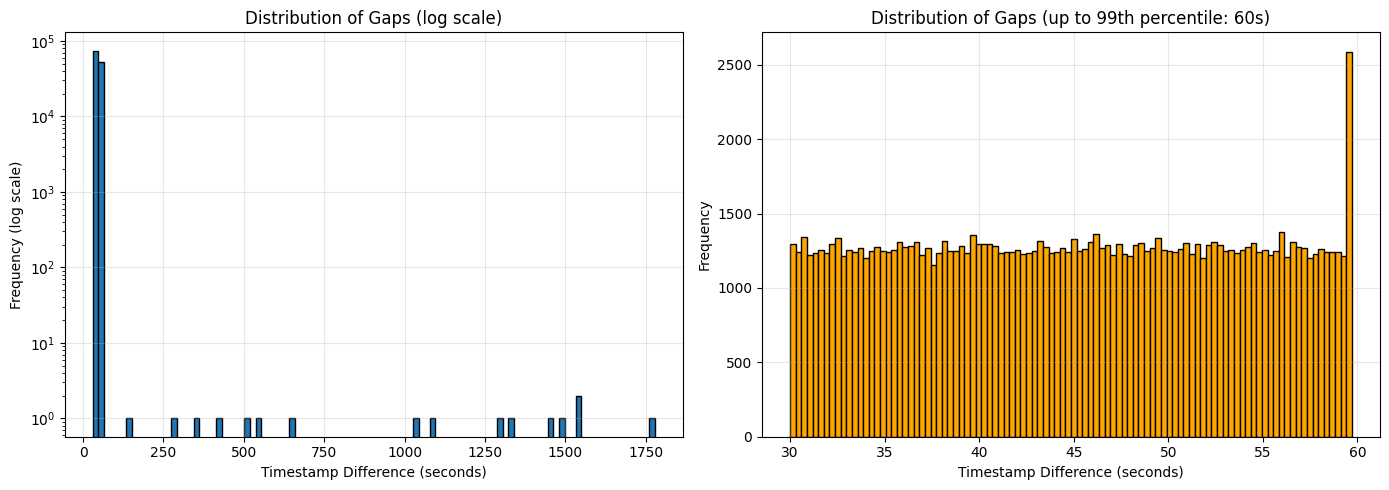

In [16]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram with log scale to handle skewed distribution
axes[0].hist(inverter_a1_raw["timestamp_diff"].dropna(), bins=100, edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_xlabel('Timestamp Difference (seconds)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Distribution of Gaps (log scale)')
axes[0].grid(True, alpha=0.3)

# Plot 2: Focus on the main distribution (clip outliers to 99th percentile)
q99 = inverter_a1_raw["timestamp_diff"].quantile(0.99)
filtered_diff = inverter_a1_raw["timestamp_diff"].dropna().clip(upper=q99)
axes[1].hist(filtered_diff, bins=100, edgecolor='black', color='orange')
axes[1].set_xlabel('Timestamp Difference (seconds)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Distribution of Gaps (up to 99th percentile: {q99:.0f}s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Time series visualization of each numeric feature

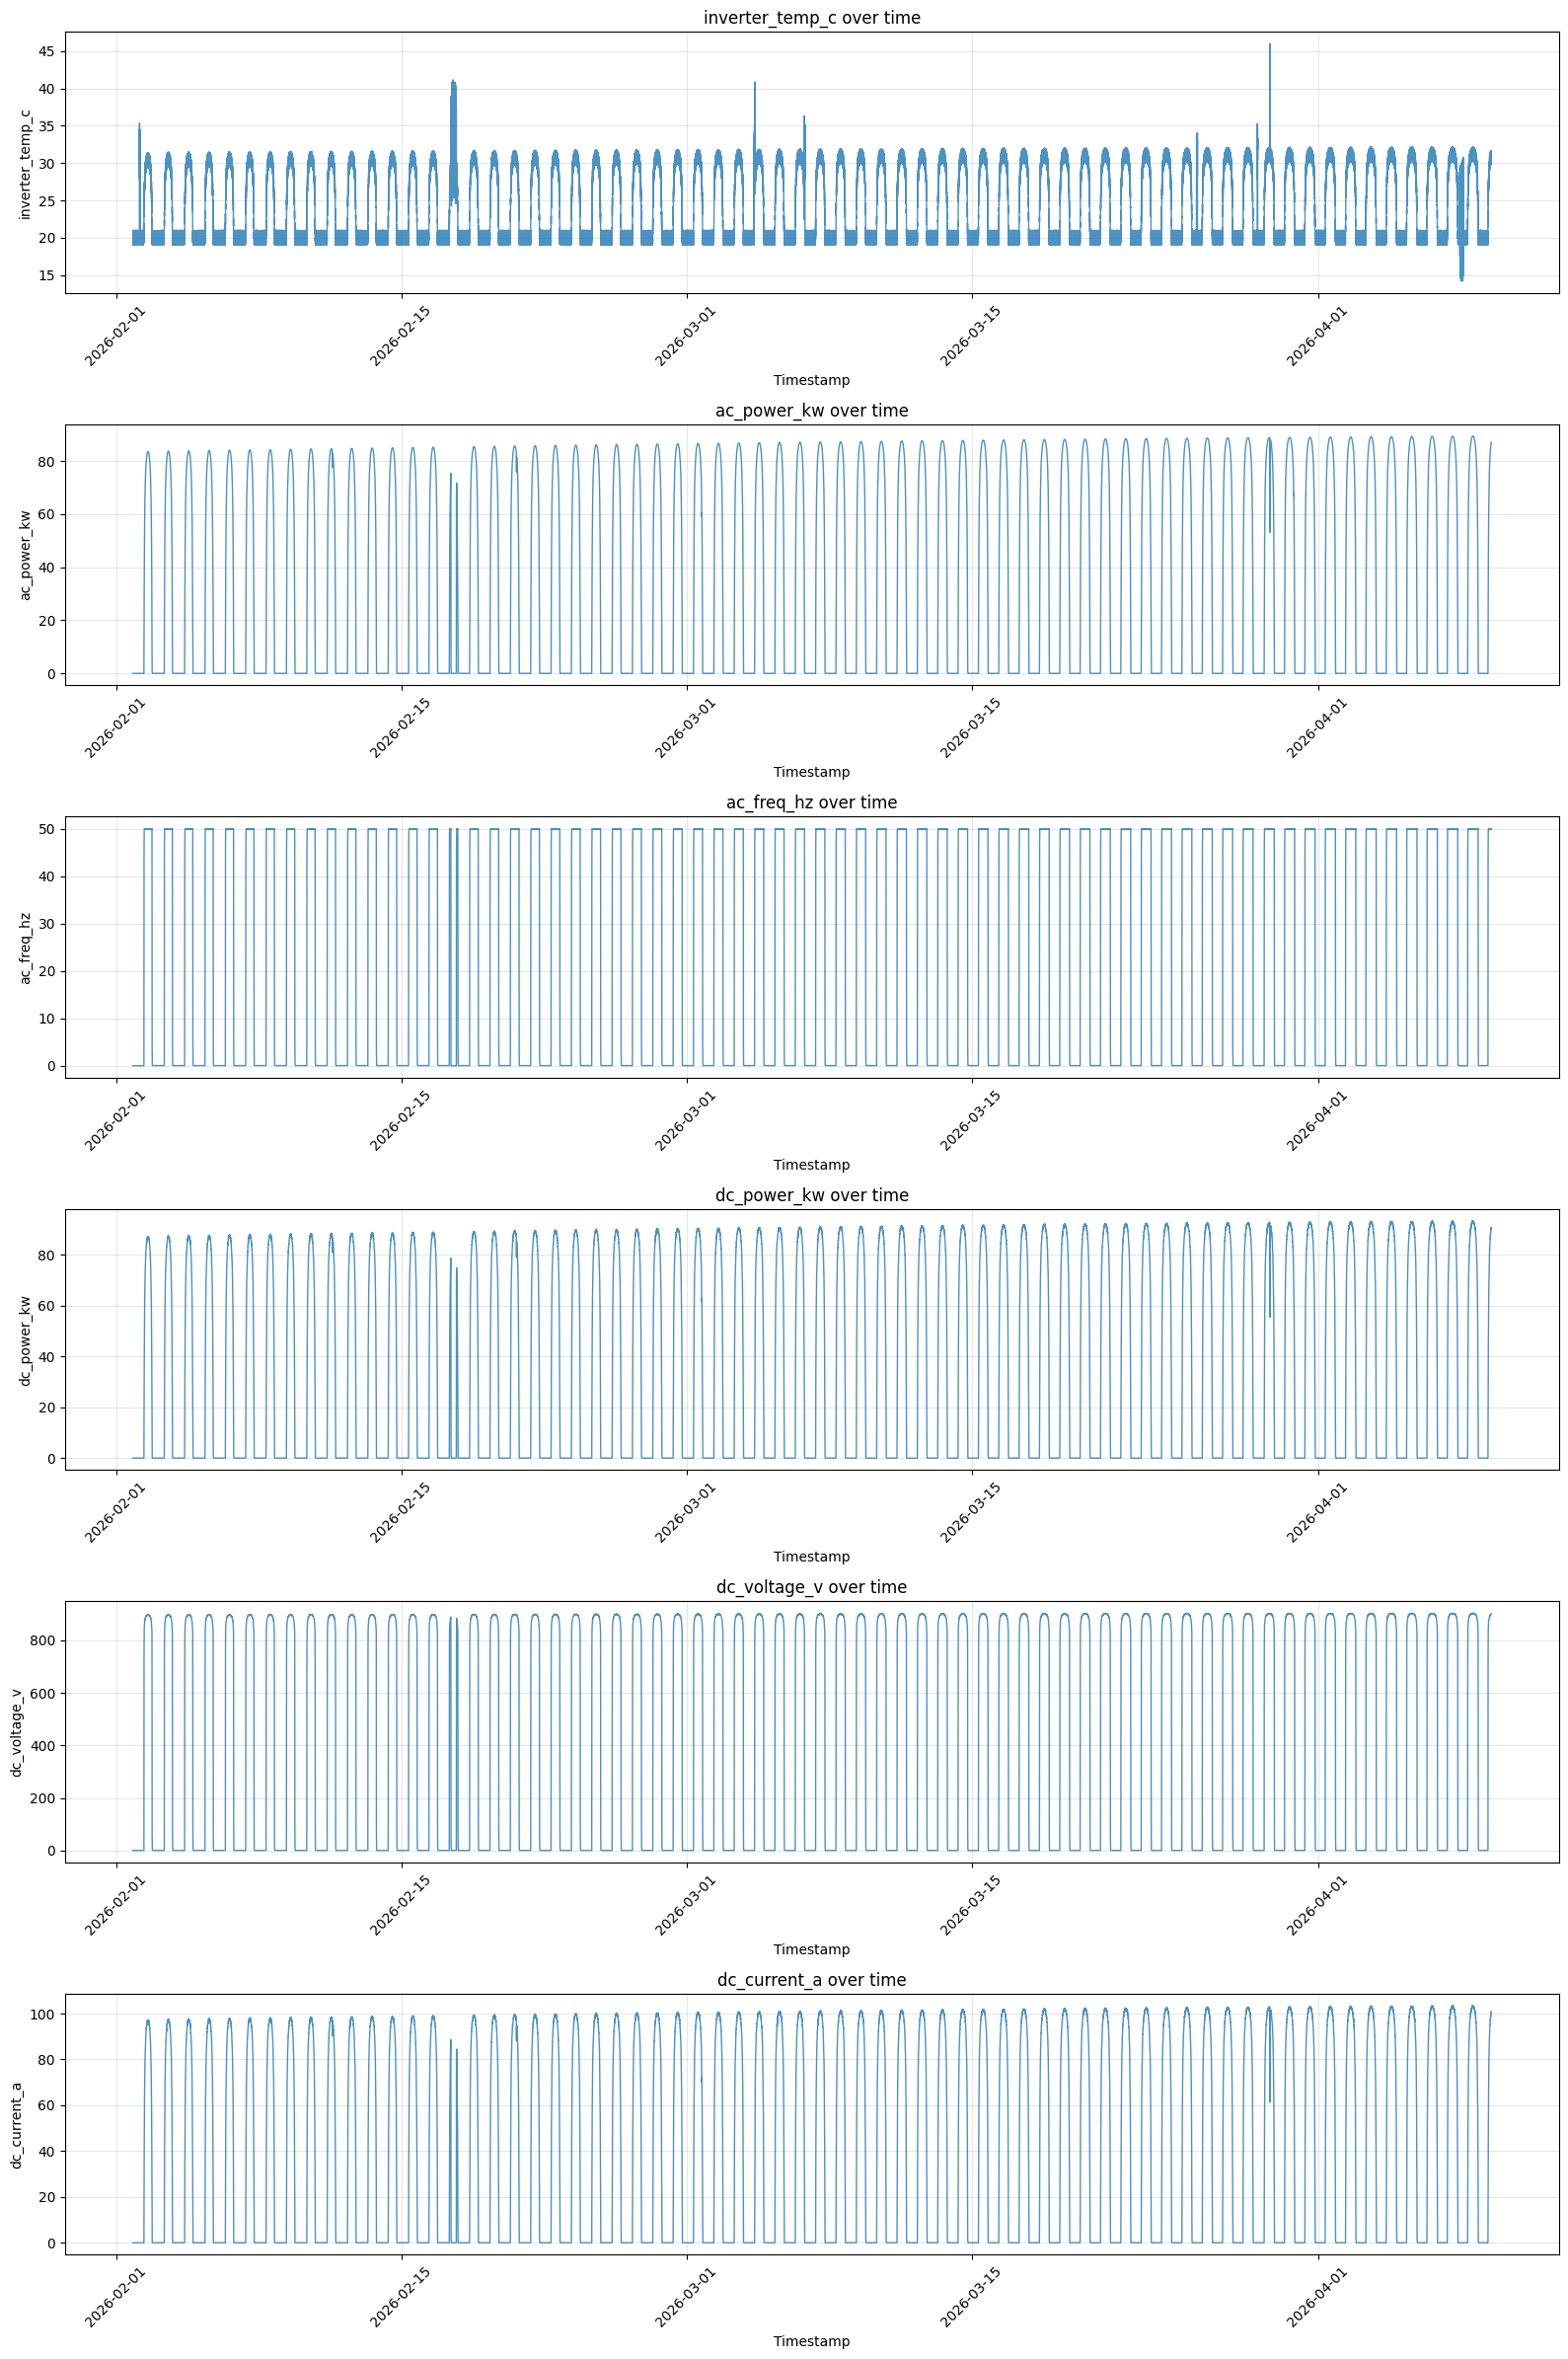

In [17]:
# Get all numeric columns except id and timestamp_diff
numeric_cols = ['inverter_temp_c', 'ac_power_kw', 'ac_freq_hz', 'dc_power_kw', 'dc_voltage_v', 'dc_current_a']

# Create subplots for each numeric column
n_cols = 1
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()  # Flatten to 1D array for easier iteration

# Plot each numeric column as a time series
for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    ax.plot(inverter_a1_raw['timestamp'], inverter_a1_raw[col], linewidth=1, alpha=0.8)
    ax.set_xlabel('Timestamp')
    ax.set_ylabel(col)
    ax.set_title(f'{col} over time')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


## Outlier detection
We will use IQR Method to detect possible outliers in the data.

We will not only use the method, we will check the outliers to consider if they provide information, such as anomalies or errors, or if they only provide wrong information.

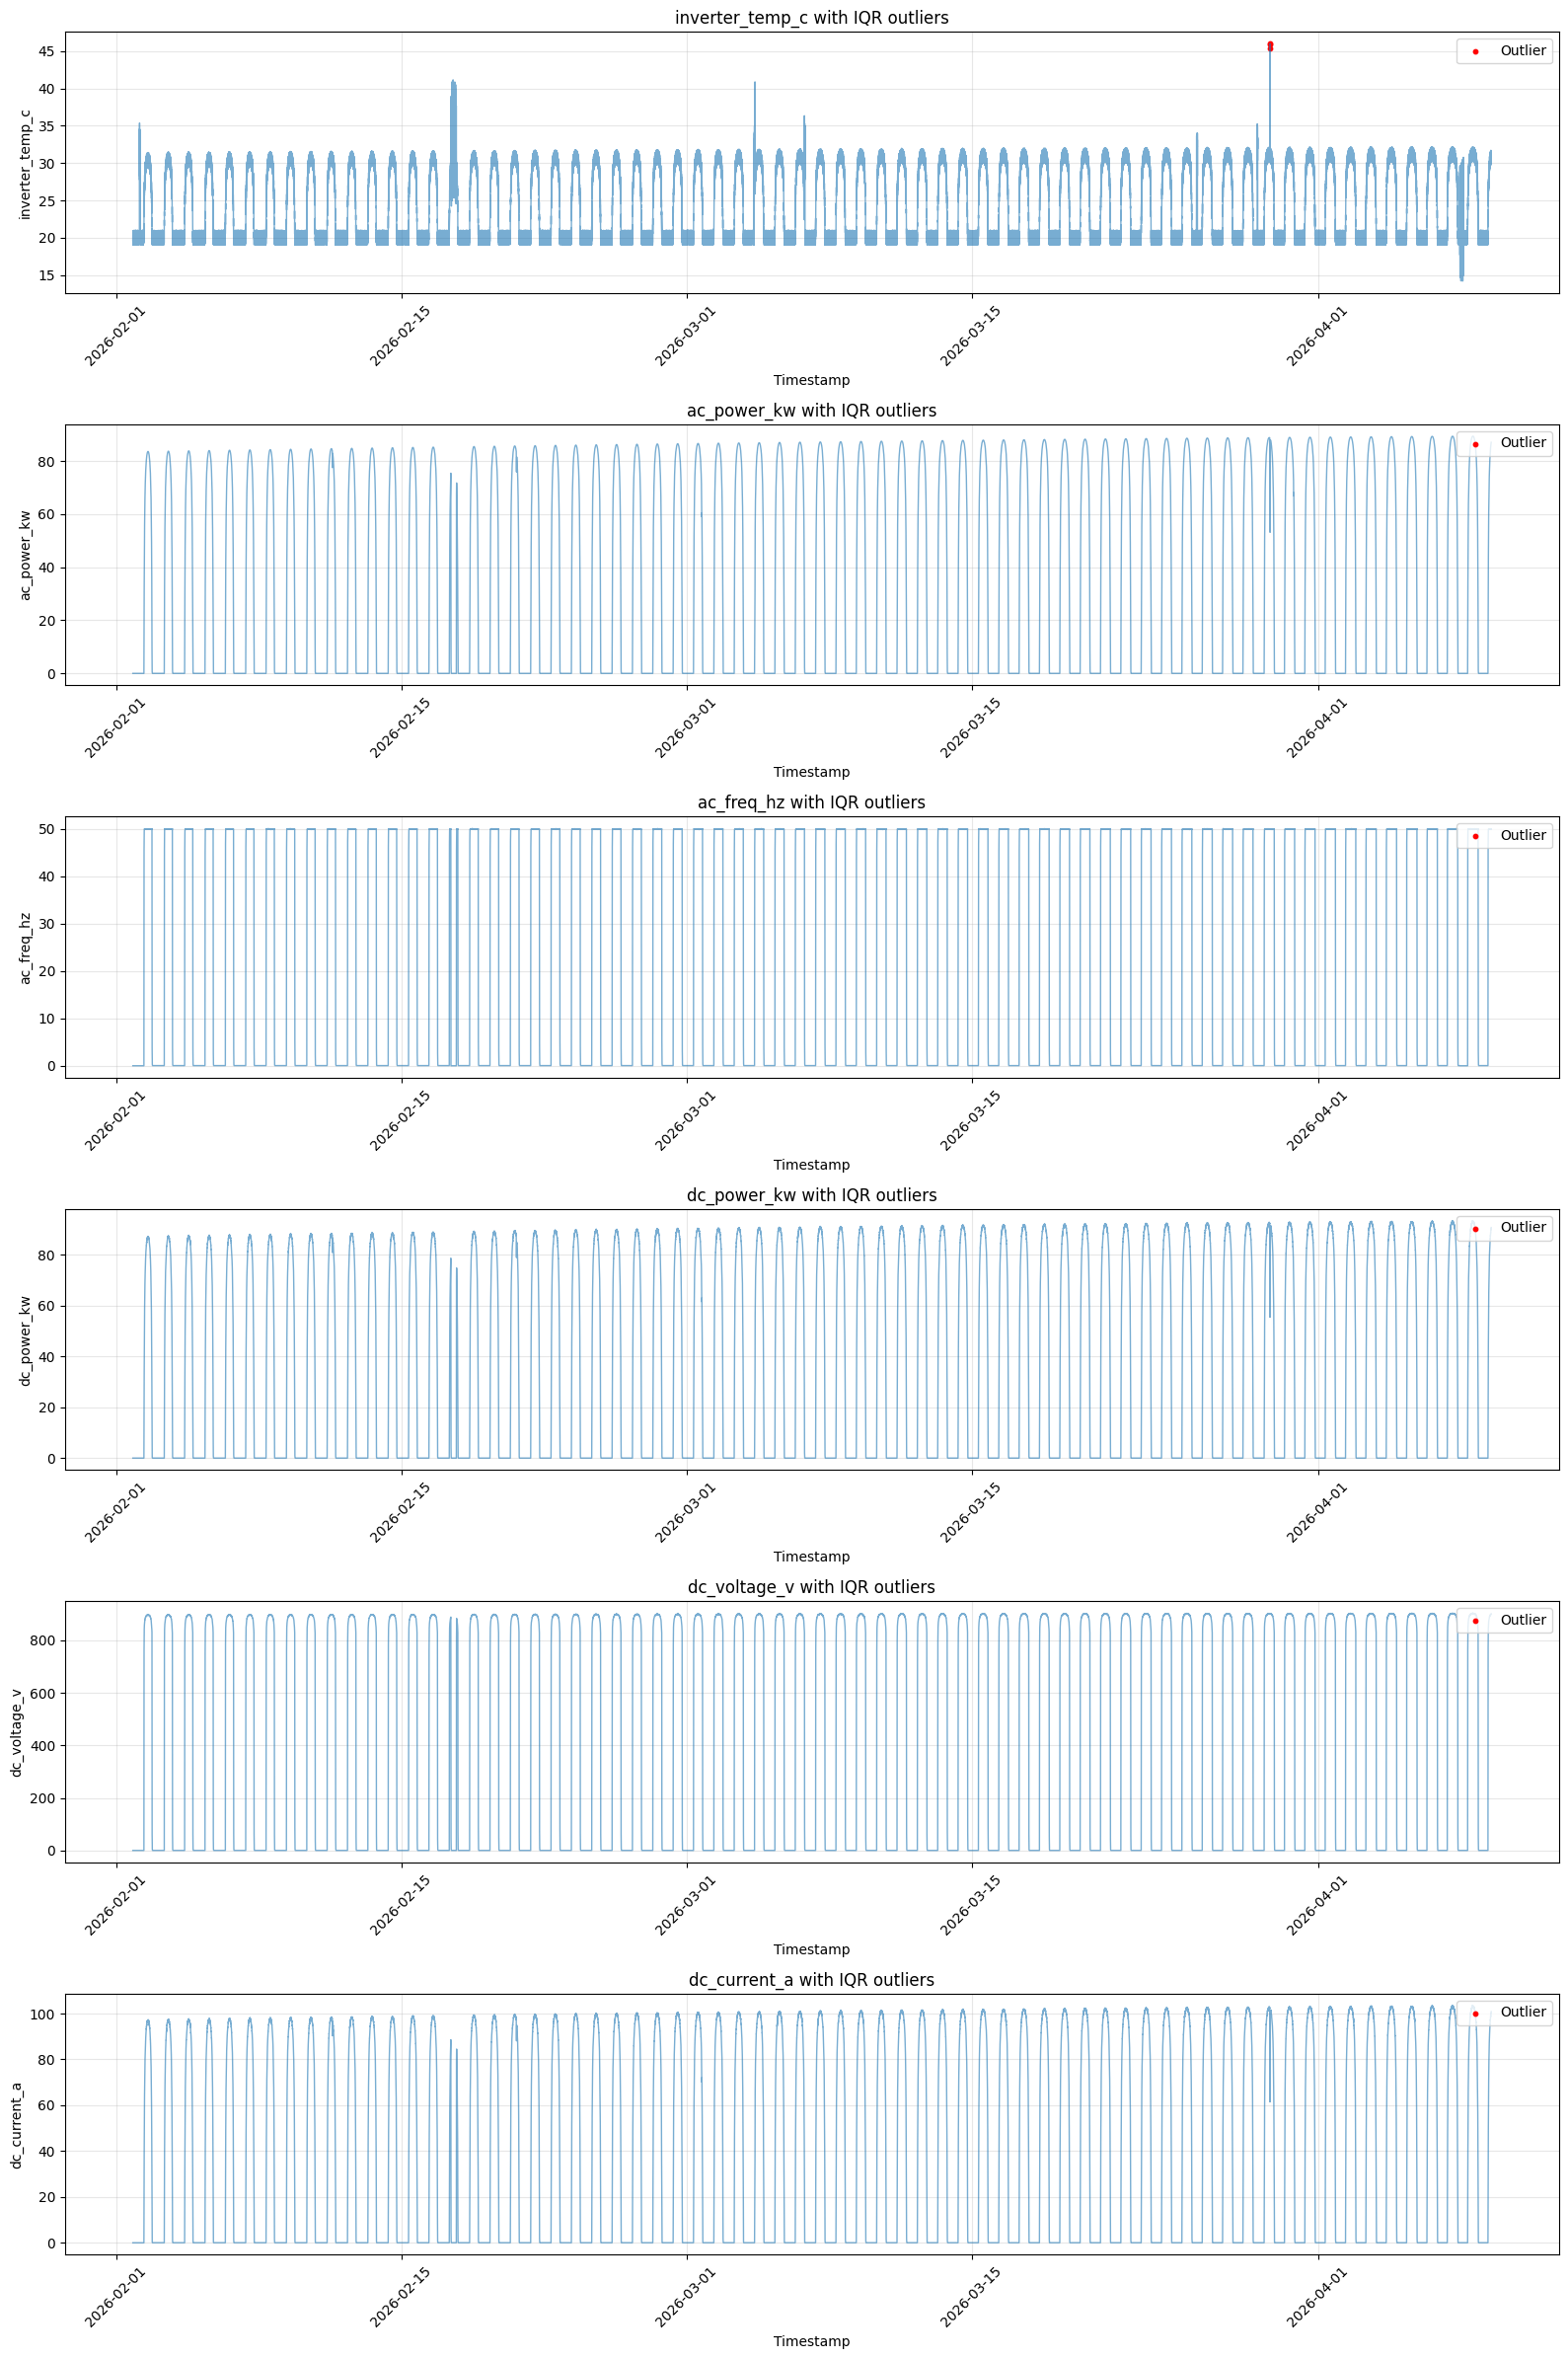

In [18]:
# Compute IQR bounds per column
q1 = inverter_a1_raw[numeric_cols].quantile(0.25)
q3 = inverter_a1_raw[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Boolean mask of outliers per column
outlier_mask = (inverter_a1_raw[numeric_cols] < lower) | (inverter_a1_raw[numeric_cols] > upper)

# Plot time series with outliers highlighted in red
n_cols = 1
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    ax.plot(inverter_a1_raw['timestamp'], inverter_a1_raw[col], linewidth=1, alpha=0.6, color='tab:blue')
    outliers = inverter_a1_raw[outlier_mask[col]]
    ax.scatter(outliers['timestamp'], outliers[col], color='red', s=10, label='Outlier')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel(col)
    ax.set_title(f'{col} with IQR outliers')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper right')

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

Check if the marked outliers with the IQR method, correspond a time with known active_failures.

In [19]:
# Check if the outliers correspond to same timestamps when active_failures > 0, which could indicate that the outliers are related to failure events.
outlier_timestamps = inverter_a1_raw[outlier_mask.any(axis=1)]['timestamp']
failure_timestamps = inverter_a1_raw[inverter_a1_raw['active_failures'] > 0]['timestamp']

# Represent the timestamps as sets to find intersections
outlier_timestamps_set = set(outlier_timestamps)
failure_timestamps_set = set(failure_timestamps)


intersection = outlier_timestamps_set.intersection(failure_timestamps_set)
print(f"Number of outlier timestamps that correspond to failure events: {len(intersection)} out of {len(outlier_timestamps_set)} outlier timestamps.")

Number of outlier timestamps that correspond to failure events: 3 out of 3 outlier timestamps.


Due to having the outliers correspond with same timestamps as knonw failures, we won't discard them, because the information they reflect could be useful for our future models.